# Project II

##### University of California - Berkeley

##### Chem277a: Data Science for the Molecular Sciences

##### Girish Krishna, Seungho Yoo, Shivani Tijare, Zander Rothering

##### Github Link: https://github.com/Zander-Rothering/Chem277a_Project_II.git

### 1) Objective

Classification of individuals as at risk for Alzheimer's disease using predictive models is critically important given its progressive, irreversible nature and status as the leading cause of dementia worldwide, representing a major and growing public health challenge (Ballard et al., 2011; Lane et al., 2018). Early detection of the disease is especially important, as Alzheimer's has a preclinical phase during which underlying pathological changes occur before clinical symptoms emerge, creating a window for intervention, improved care planning, and the potential slowing of cognitive decline through treatment (Jack et al., 2018; Lane et al., 2018). At the same time, challenges in diagnosis highlight the importance of methods that can integrate a diverse range of features such as age, cognitive scores, medical history, and other risk factors (Ballard et al., 2011). Predictive classification models are well suited to this task, as they capture relationships within data that may not be identified using conventional means. As the prevalence of Alzheimer’s continues to rise and emphasis on risk reduction becomes increasingly important, classification pipelines emerge as an effective means of enhancing diagnostic accuracy, supporting clinical decision-making, and advancing personalized medicine, contributing to improved disease management and healthcare outcomes (Ballard et al., 2011; Lane et al., 2018).

The objective of this project is to provide an overview of a classification pipeline for an Alzheimer's disease dataset using multiple models for classification. The project demonstrates how Alzheimer's data can be analyzed, preprocessed, and ultimately used by a predictive model to classify individuals as having Alzheimer's disease or not. The pipeline begins with exploratory data analysis of the dataset, providing context regarding related features, patterns in the data, and the distribution of data within the feature space. This data analysis is followed by encoding of data features into suitable values for classification models, feature selection for improved model performance, and splitting of the data into training and validation sets. Finally, the project implements and compares the classification of individuals using four models (Logistic Regression, Decision Trees, Random Forest, and Support Vector machines) to evaluate their ability to predict Alzheimer's disease outcomes based on input features. This approach to predictive modeling, provides a concise approach to capturing the underlying relationships in data that can be used to predict Alzheimer's disease.

<br>

### 2) Dependencies

Prior to running the pipeline, the following libraries should be imported for data analysis, visualization, encoding, and predicitive modeling.

In [50]:
import warnings
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from category_encoders import BinaryEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

<br>

### 3) EDA

dataset has columns like Alzheimer's Diagnosis with a curly apostrophe (because whoever made the CSV used Word or similar). When you type code, your keyboard produces a straight apostrophe. Python sees these as different characters, causing KeyError.

In [52]:
pd.set_option('display.max_columns', None)
alz_data = pd.read_csv('alzheimers_prediction_dataset.csv')
alz_data.columns = alz_data.columns.str.replace('\u2019', "'", regex=False)
#alz_data = pd.read_csv('alzheimers_prediction_dataset.csv')
alz_data.head(15)

,Country,Age,Gender,Education Level,BMI,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,Cholesterol Level,Family History of Alzheimer's,Cognitive Test Score,Depression Level,Sleep Quality,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Income Level,Stress Levels,Urban vs Rural Living,Alzheimer's Diagnosis
0,Spain,90,Male,1,33.0,Medium,Never,Occasionally,No,No,Normal,No,90,Low,Poor,Healthy,High,Retired,Single,No,Low,Medium,High,Urban,No
1,Argentina,72,Male,7,29.9,Medium,Former,Never,No,No,Normal,No,65,Low,Good,Healthy,Medium,Unemployed,Widowed,No,High,Low,High,Urban,No
2,South Africa,86,Female,19,22.9,High,Current,Occasionally,No,Yes,Normal,No,43,High,Good,Average,Medium,Employed,Single,No,Low,Medium,High,Rural,No
3,China,53,Male,17,31.2,Low,Never,Regularly,Yes,No,Normal,No,81,Medium,Average,Healthy,Medium,Retired,Single,No,High,Medium,Low,Rural,No
4,Sweden,58,Female,3,30.0,High,Former,Never,Yes,No,Normal,No,49,High,Poor,Unhealthy,High,Employed,Married,No,Low,Medium,High,Rural,No
5,Spain,55,Female,2,34.0,Medium,Current,Never,No,No,High,Yes,36,Low,Average,Healthy,Low,Retired,Married,No,Low,Medium,High,Rural,No
6,South Korea,91,Female,18,24.1,High,Former,Occasionally,No,Yes,Normal,No,68,High,Poor,Average,High,Employed,Widowed,No,High,Low,Medium,Urban,No
7,China,67,Female,11,23.6,Low,Current,Regularly,No,No,High,No,49,Low,Good,Unhealthy,Low,Unemployed,Widowed,No,Low,Medium,High,Urban,Yes
8,China,84,Female,11,22.0,High,Current,Regularly,No,No,High,No,55,Low,Good,Average,High,Employed,Single,No,Medium,Low,Low,Rural,No
9,Germany,72,Female,11,32.4,Medium,Never,Occasionally,No,Yes,Normal,Yes,50,High,Poor,Average,High,Employed,Single,No,Low,Low,Medium,Rural,No


In [53]:
alz_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74283 entries, 0 to 74282
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               74283 non-null  object 
 1   Age                                   74283 non-null  int64  
 2   Gender                                74283 non-null  object 
 3   Education Level                       74283 non-null  int64  
 4   BMI                                   74283 non-null  float64
 5   Physical Activity Level               74283 non-null  object 
 6   Smoking Status                        74283 non-null  object 
 7   Alcohol Consumption                   74283 non-null  object 
 8   Diabetes                              74283 non-null  object 
 9   Hypertension                          74283 non-null  object 
 10  Cholesterol Level                     74283 non-null  object 
 11  Family History 

In [54]:
alz_data.nunique()

Country                                  20
Age                                      45
Gender                                    2
Education Level                          20
BMI                                     166
Physical Activity Level                   3
Smoking Status                            3
Alcohol Consumption                       3
Diabetes                                  2
Hypertension                              2
Cholesterol Level                         2
Family History of Alzheimer's             2
Cognitive Test Score                     70
Depression Level                          3
Sleep Quality                             3
Dietary Habits                            3
Air Pollution Exposure                    3
Employment Status                         3
Marital Status                            3
Genetic Risk Factor (APOE-ε4 allele)      2
Social Engagement Level                   3
Income Level                              3
Stress Levels                   

In [55]:
# Feature Separation

alz_target = alz_data["Alzheimer's Diagnosis"]
alz_data_x = alz_data.drop(columns=["Alzheimer's Diagnosis"])
alz_data_copy = alz_data_x.copy()

# Numeric Features
numeric_features = ['Age', 'BMI', 'Cognitive Test Score', 'Education Level']
alz_numeric = alz_data_copy[numeric_features]
alz_numeric.head()

,Age,BMI,Cognitive Test Score,Education Level
0,90,33.0,90,1
1,72,29.9,65,7
2,86,22.9,43,19
3,53,31.2,81,17
4,58,30.0,49,3


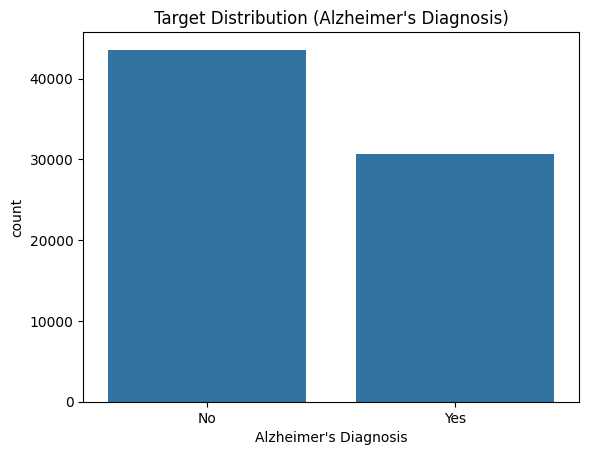

In [56]:
# Target Distribution
alz_target.value_counts(normalize=True)
sns.countplot(x=alz_target)
plt.title("Target Distribution (Alzheimer's Diagnosis)")
plt.show()

<Axes: >

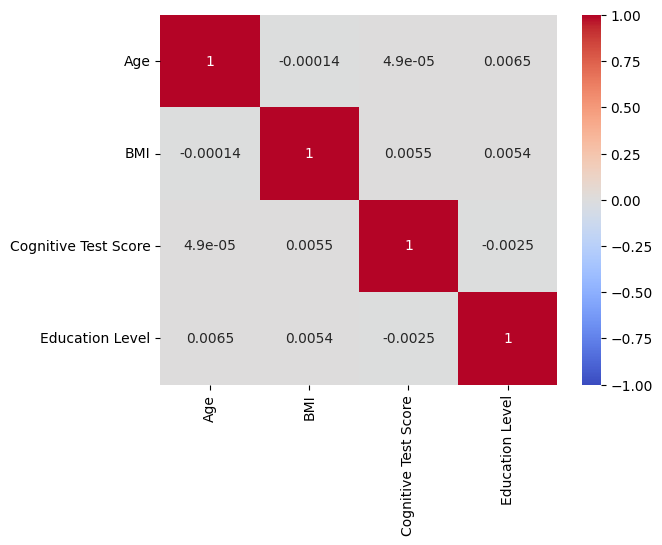

In [57]:
sns.heatmap(alz_numeric.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)

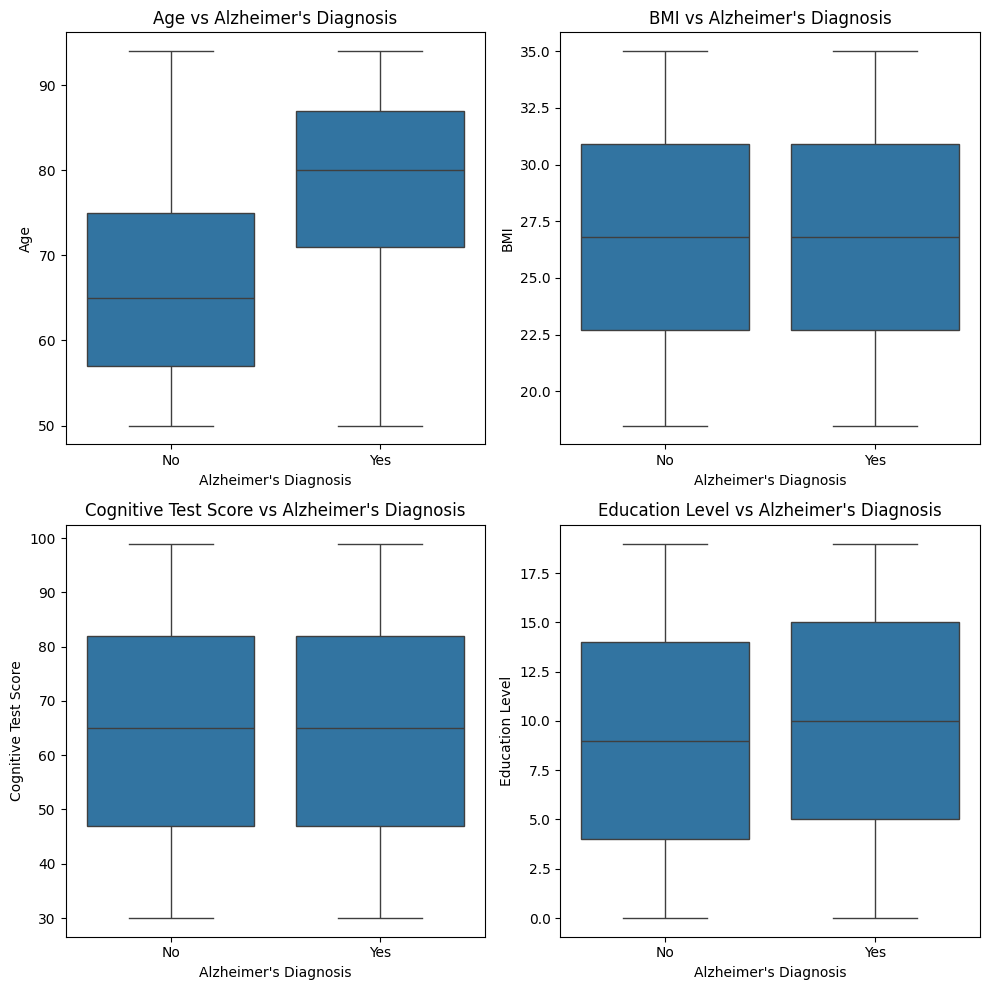

In [58]:
alz_columns_num = alz_numeric.columns.tolist()

cols = len(alz_columns_num)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
for i, column in enumerate(alz_columns_num):
    sns.boxplot(data=alz_data, x="Alzheimer's Diagnosis", y=column, ax=axes[i])
    axes[i].set_title(f"{column} vs Alzheimer's Diagnosis")
plt.tight_layout()
plt.show()

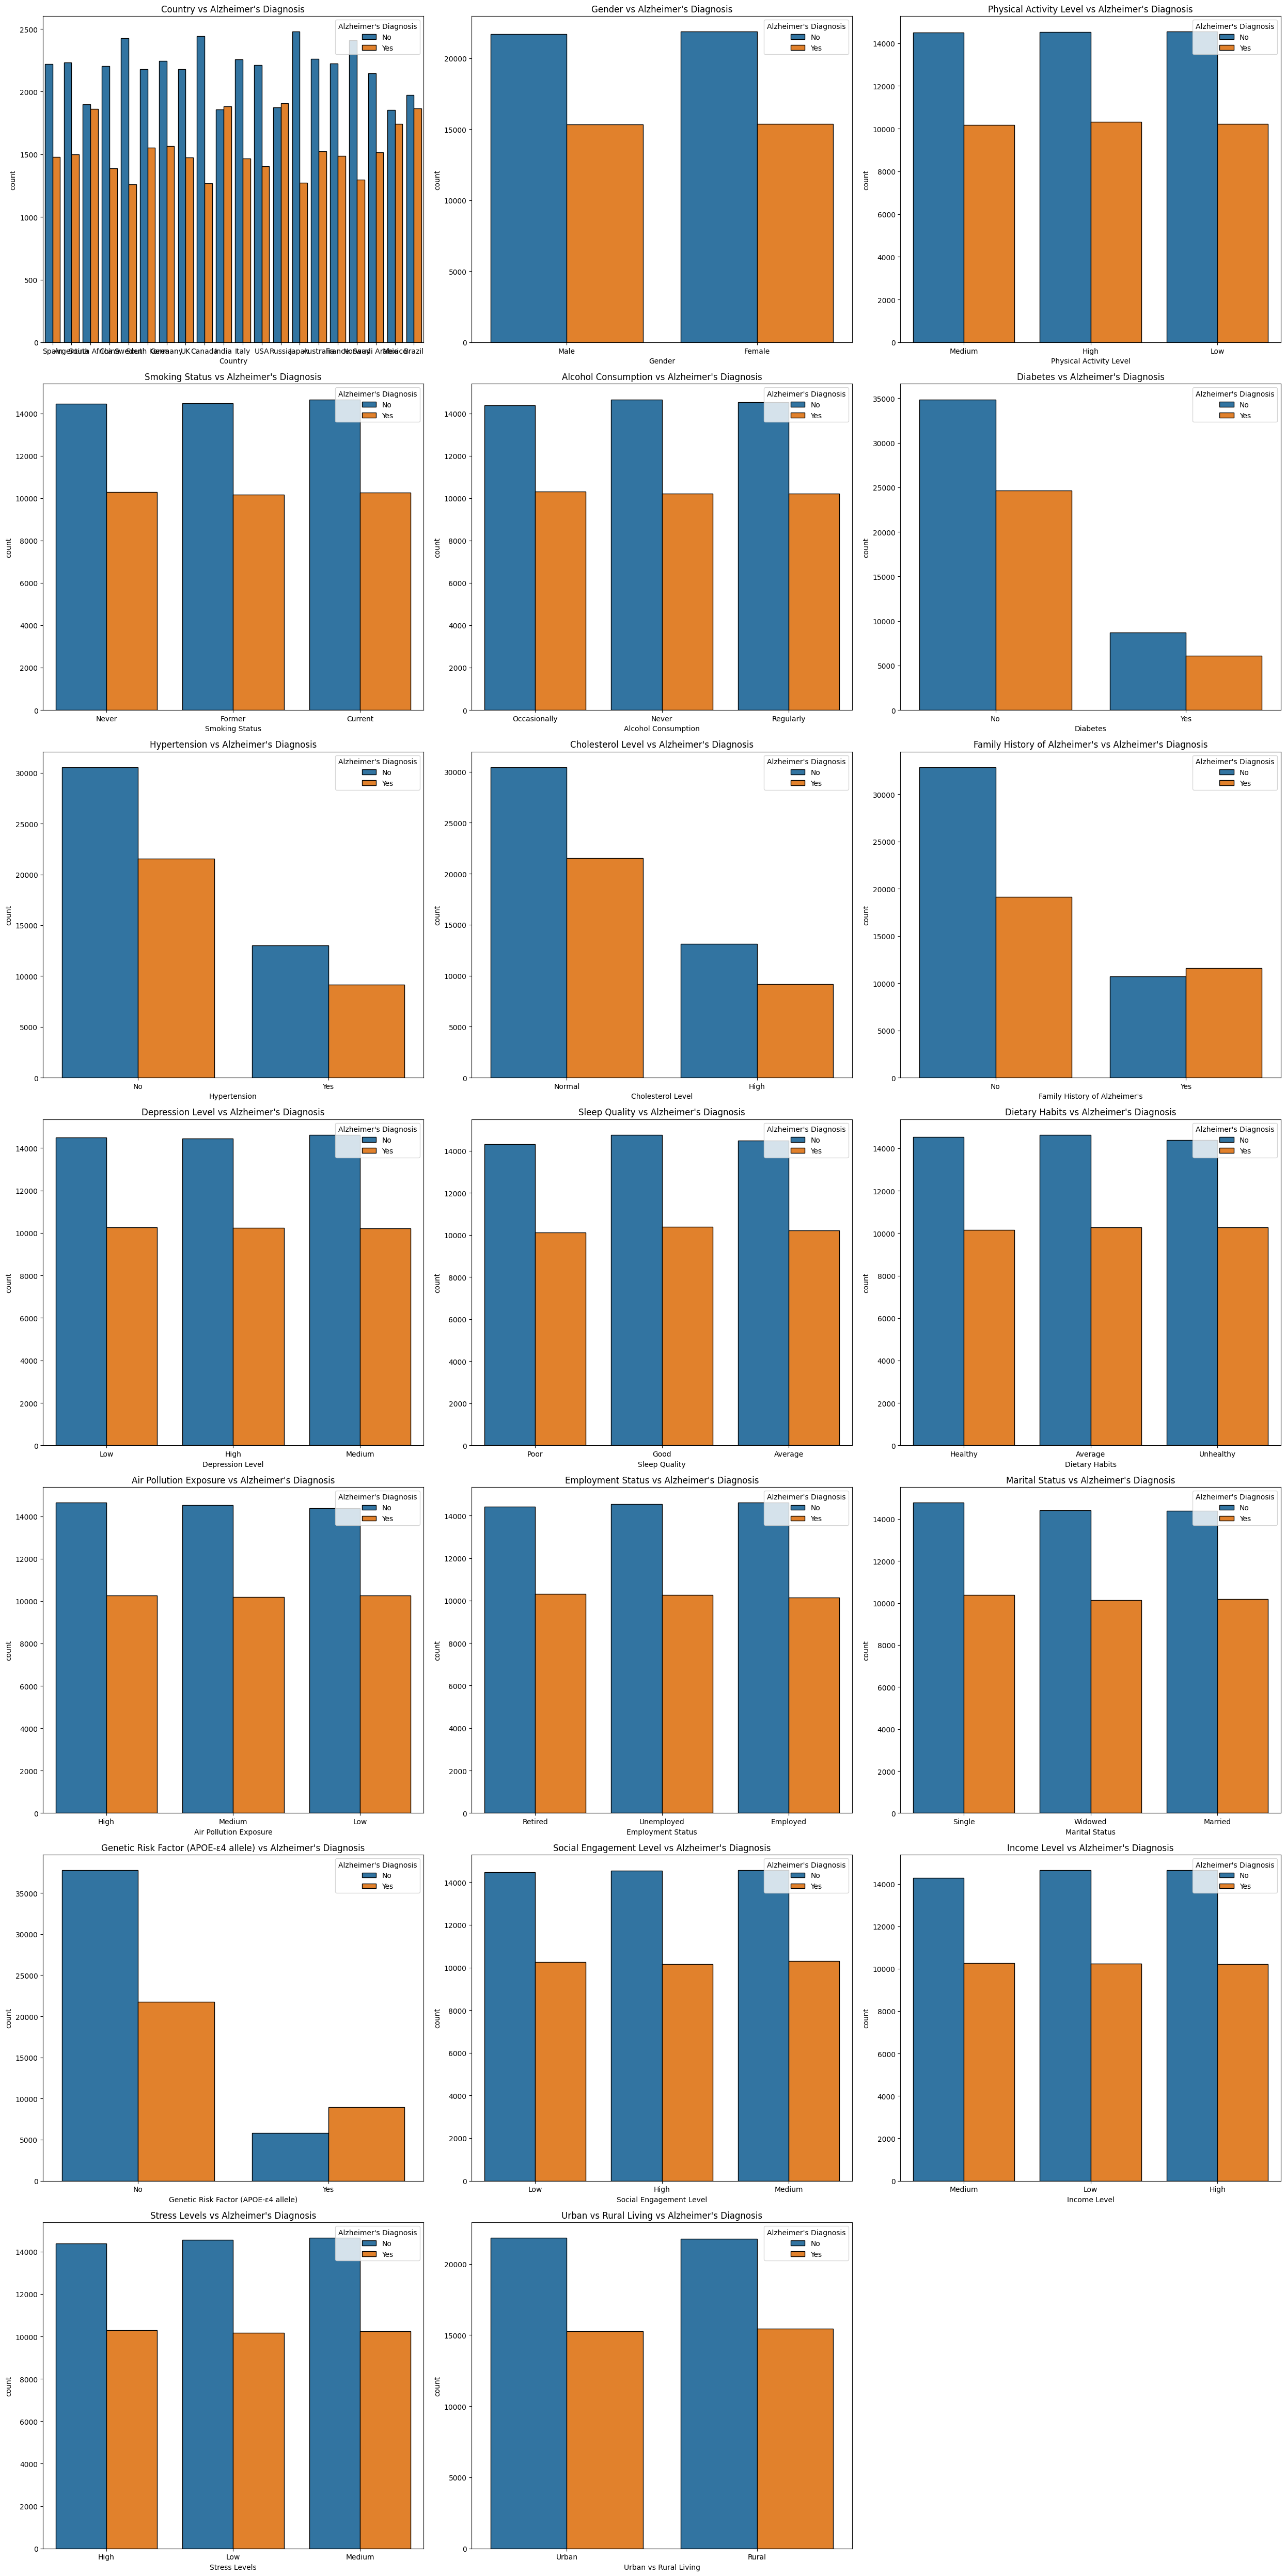

In [59]:
alz_data_cat = alz_data.drop(columns=numeric_features + ["Alzheimer's Diagnosis"])
alz_columns_cat = alz_data_cat.columns.tolist()

fig, axes = plt.subplots(7, 3, figsize=(25, 50))
axes = axes.flatten()

for i, column in enumerate(alz_columns_cat):
    sns.countplot(data=alz_data, x=column, hue="Alzheimer's Diagnosis",
                  ax=axes[i], edgecolor='black')
    axes[i].set_title(f"{column} vs Alzheimer's Diagnosis")

# Hide any unused subplots (in case grid is bigger than feature count)
for j in range(len(alz_columns_cat), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [60]:
# Correlation

from sklearn.feature_selection import mutual_info_classif

mi_numeric = mutual_info_classif(alz_numeric, alz_target, random_state=RANDOM_STATE)
pd.Series(mi_numeric, index=alz_numeric.columns).sort_values(ascending=False)

Age                     0.108008
Education Level         0.001597
BMI                     0.000000
Cognitive Test Score    0.000000
dtype: float64

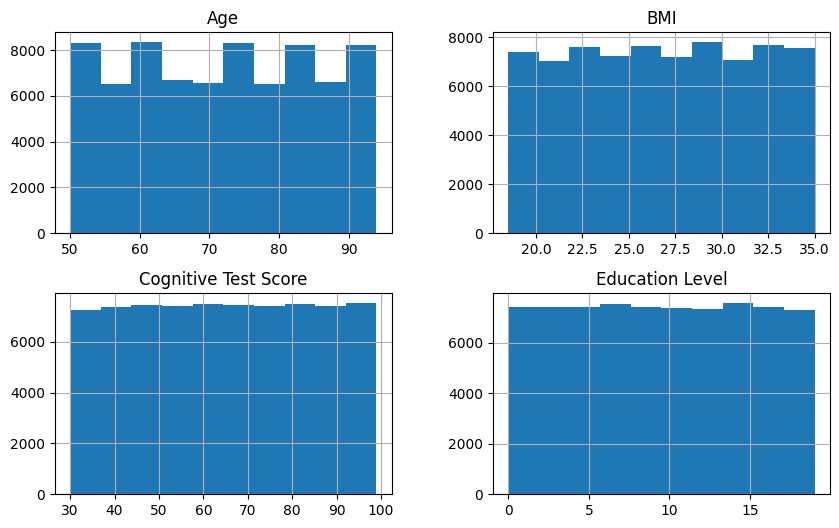

In [61]:
# Distribution + Outliers
df_alz = alz_data_x.copy()
df_alz[numeric_features].hist(figsize=(10,6))
plt.show()

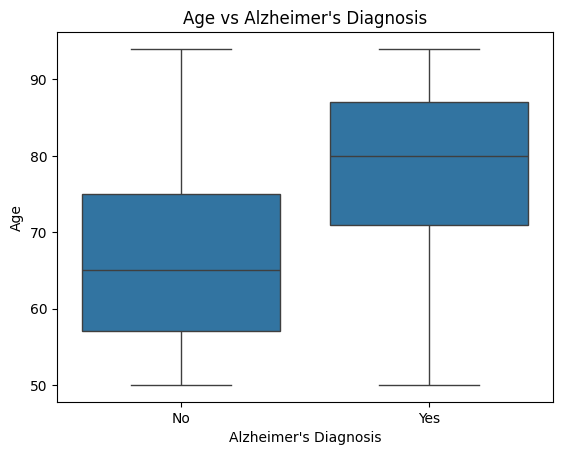

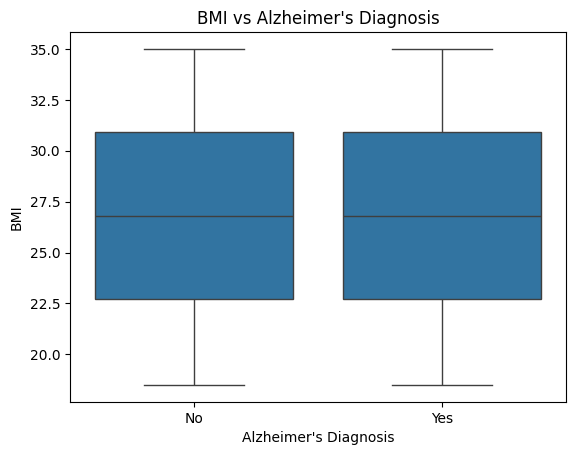

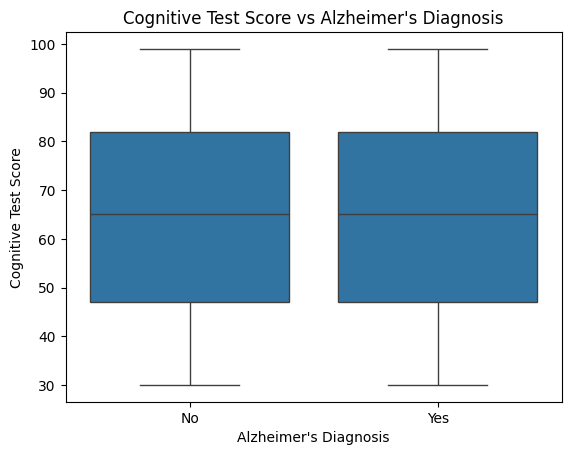

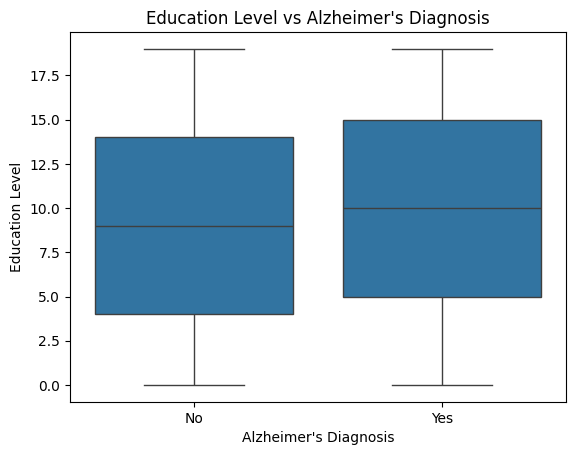

In [62]:
# Boxplots with interpretation
for col in numeric_features:
    sns.boxplot(x=alz_target, y=alz_data[col])
    plt.title(f"{col} vs Alzheimer's Diagnosis")
    plt.show()

    alz_columns_num = alz_numeric.columns.tolist()

In [63]:
from sklearn.feature_selection import chi2

# Use OrdinalEncoder (feature-side) rather than LabelEncoder (target-side).
ord_enc_for_chi = OrdinalEncoder()
cat_encoded = pd.DataFrame(
    ord_enc_for_chi.fit_transform(alz_data_cat),
    columns=alz_data_cat.columns,
)

chi_scores, p_vals = chi2(cat_encoded, alz_target)
chi_results = pd.DataFrame({
    "Feature": cat_encoded.columns,
    "chi2": chi_scores,
    "p-value": p_vals
}).sort_values(by="p-value")

chi_results

,Feature,chi2,p-value
15,Genetic Risk Factor (APOE-ε4 allele),2252.840897,0.000000e+00
8,Family History of Alzheimer's,1032.199803,1.800110e-226
0,Country,3.558888,5.922741e-02
17,Income Level,1.912355,1.667019e-01
18,Stress Levels,1.077819,2.991860e-01
3,Smoking Status,0.677628,4.104049e-01
19,Urban vs Rural Living,0.626741,4.285532e-01
13,Employment Status,0.611408,4.342582e-01
11,Dietary Habits,0.522012,4.699847e-01
2,Physical Activity Level,0.429121,5.124206e-01


### 4) Feature Encoding

In [64]:
df_alz = alz_data_x.copy()

binary_features = ['Gender', 'Smoking Status', 'Alcohol Consumption', 'Diabetes', 'Hypertension',
                   'Cholesterol Level', "Family History of Alzheimer's", 'Sleep Quality',
                   'Dietary Habits', 'Employment Status', 'Marital Status',
                   'Genetic Risk Factor (APOE-ε4 allele)', 'Urban vs Rural Living']
ordinal_features = ['Physical Activity Level', 'Depression Level', 'Air Pollution Exposure',
                    'Social Engagement Level', 'Income Level', 'Stress Levels']
numeric_features = ['Age', 'Education Level', 'BMI', 'Cognitive Test Score']
high_card_features = ['Country']

# One-hot encode binary/nominal columns only, then cast to int
df_alz_bin = pd.get_dummies(df_alz[binary_features], drop_first=True).astype(int)

# Ordinal encoding
ordinal_categories = [['Low', 'Medium', 'High']] * len(ordinal_features)
ord_encoder = OrdinalEncoder(categories=ordinal_categories)
df_ordinal = pd.DataFrame(
    ord_encoder.fit_transform(df_alz[ordinal_features]),
    columns=ordinal_features,
    index=df_alz.index,
)

# Binary encoding for high-cardinality Country
bin_encoder = BinaryEncoder(cols=['Country'])
df_country = bin_encoder.fit_transform(df_alz[high_card_features])

# Numeric features pass through
df_numeric = df_alz[numeric_features].copy()

# Combine all
df_alz_encoded = pd.concat([df_country, df_alz_bin, df_ordinal, df_numeric], axis=1)
df_alz_encoded.head()

,Country_0,Country_1,Country_2,Country_3,Country_4,Gender_Male,Smoking Status_Former,Smoking Status_Never,Alcohol Consumption_Occasionally,Alcohol Consumption_Regularly,Diabetes_Yes,Hypertension_Yes,Cholesterol Level_Normal,Family History of Alzheimer's_Yes,Sleep Quality_Good,Sleep Quality_Poor,Dietary Habits_Healthy,Dietary Habits_Unhealthy,Employment Status_Retired,Employment Status_Unemployed,Marital Status_Single,Marital Status_Widowed,Genetic Risk Factor (APOE-ε4 allele)_Yes,Urban vs Rural Living_Urban,Physical Activity Level,Depression Level,Air Pollution Exposure,Social Engagement Level,Income Level,Stress Levels,Age,Education Level,BMI,Cognitive Test Score
0,0,0,0,0,1,1,0,1,1,0,0,0,1,0,0,1,1,0,1,0,1,0,0,1,1.0,0.0,2.0,0.0,1.0,2.0,90,1,33.0,90
1,0,0,0,1,0,1,1,0,0,0,0,0,1,0,1,0,1,0,0,1,0,1,0,1,1.0,0.0,1.0,2.0,0.0,2.0,72,7,29.9,65
2,0,0,0,1,1,0,0,0,1,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,2.0,2.0,1.0,0.0,1.0,2.0,86,19,22.9,43
3,0,0,1,0,0,1,0,1,0,1,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0.0,1.0,1.0,2.0,1.0,0.0,53,17,31.2,81
4,0,0,1,0,1,0,1,0,0,0,1,0,1,0,0,1,0,1,0,0,0,0,0,0,2.0,2.0,2.0,0.0,1.0,2.0,58,3,30.0,49


### 4.5) Feature Selection

Features are partitioned into four groups and encoded according to their type:

Binary / nominal** features get one-hot encoded with `drop_first=True` to avoid the dummy-variable trap.
Ordinal features (Low/Medium/High scales) get explicit ordinal encoding so the model sees a meaningful ordering.
High-cardinality features (`Country`) are binary-encoded to limit dimensionality.
Numeric features pass through unchanged here and are scaled later inside the train pipeline.

To prevent encoder leakage, the categorical encoders are fit only on training data later in the pipeline. The cell below produces a fully-encoded *exploratory* dataframe used only for the correlation and mutual-information analyses in Section 4.5.


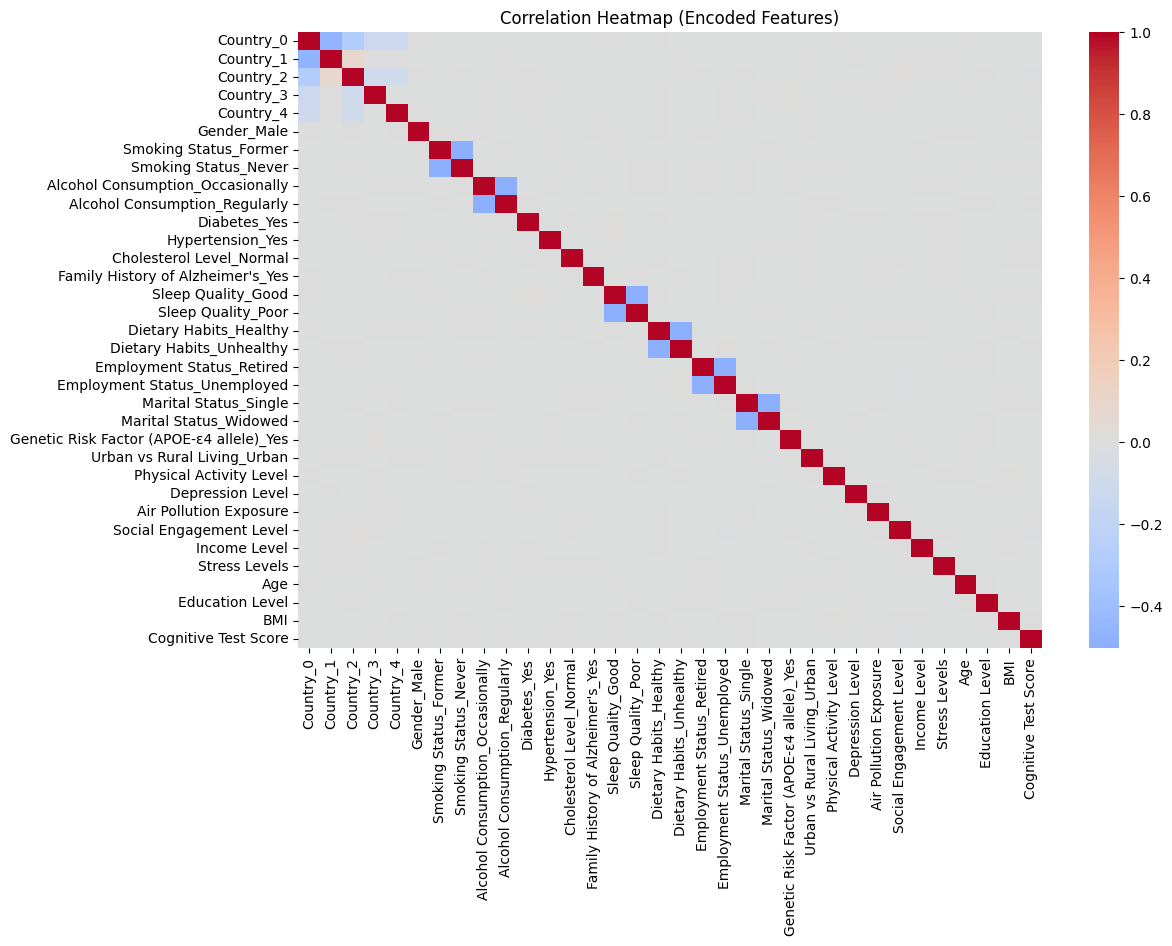

In [65]:
# Correlation on FULL encoded dataset

corr = df_alz_encoded.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Encoded Features)")
plt.show()

The correlation heatmap of encoded features shows that more of the features are independent of one another. The only notable correlations appear within dummy-encoded groups like Smoking Status_Former and Smoking Status_Never are negatively correlated which is expected. This absence of multicollinearity suggests that feature redundancy is not really a major concern and indepented information will be carried into the models.

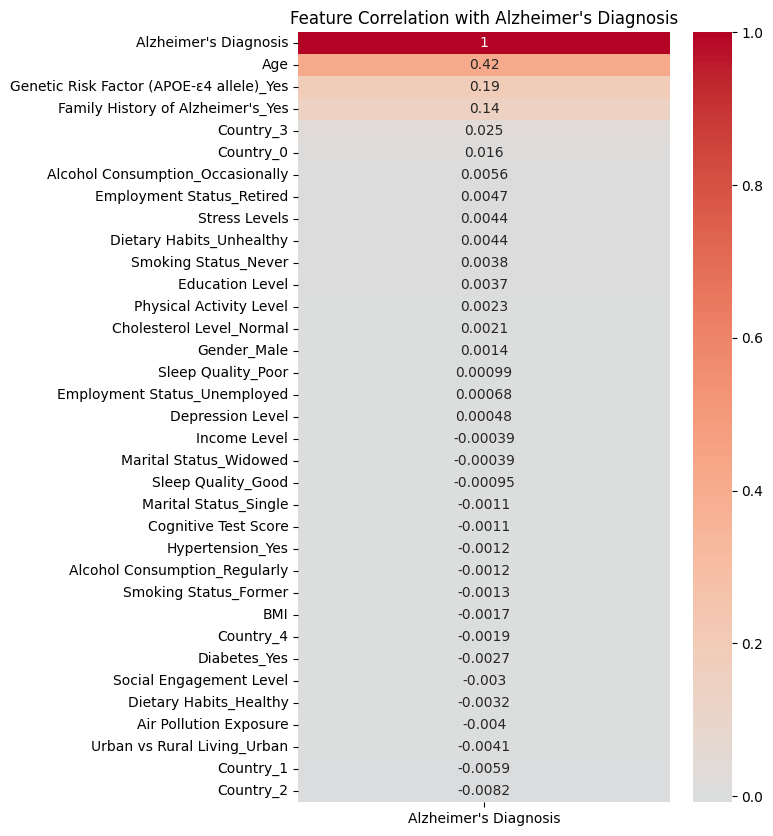

In [66]:
# correlation with target

# Make a copy so we do not change the original encoded dataframe
df_corr = df_alz_encoded.copy()

# Add target back into the encoded dataframe
df_corr["Alzheimer's Diagnosis"] = alz_target.map({"No": 0, "Yes": 1})

# Correlation with target
corr_target = df_corr.corr()["Alzheimer's Diagnosis"].sort_values(ascending=False)
plt.figure(figsize=(6,10))
sns.heatmap(corr_target.to_frame(), annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation with Alzheimer's Diagnosis")
plt.show()

Here age shows the strongest linear correlation with the Alxzheimer's diagnosis (r = 0.42), which is consistent witht eh mutual information results. Genetic Risk Factor (APOE-ε4 allele) (r = 0.19) and Family History of Alzheimer's (r = 0.14) follow as the next most correlated features. The rest of the fetures show correlations close to 0 which suggests a weaker linear relationship with the target.

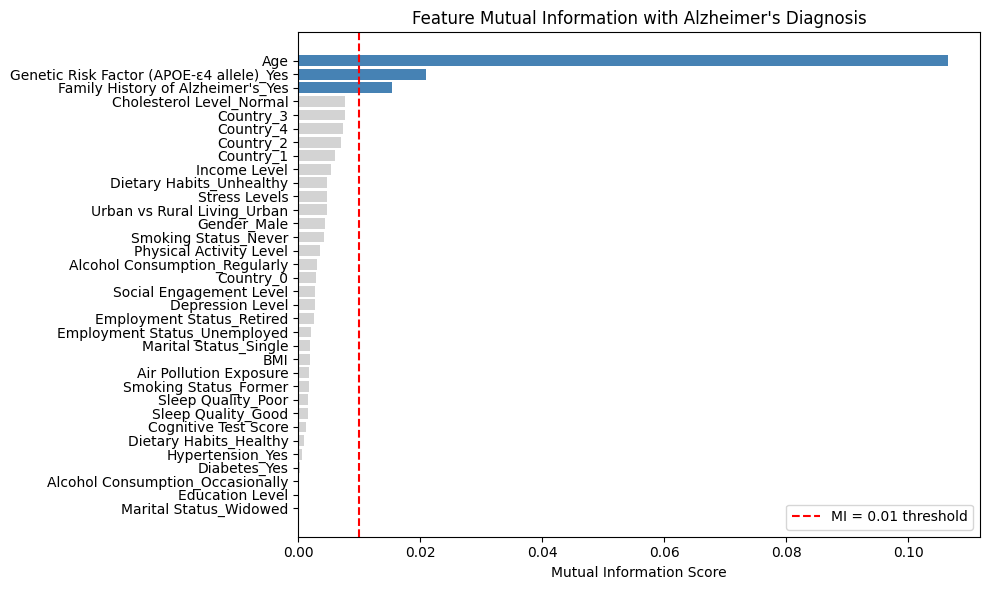

In [67]:
from sklearn.feature_selection import mutual_info_classif

# Make a clean X and y
X_mi = df_alz_encoded.copy()
y_mi = alz_target.map({"No": 0, "Yes": 1})

# Mutual information
mi = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)

#viewing as a bar chart
plt.figure(figsize=(10, 6))
mi_series_plot = mi_series[mi_series.index != "Alzheimer's Diagnosis"]
colors = ['steelblue' if v >= 0.01 else 'lightgray' for v in mi_series_plot]
plt.barh(mi_series_plot.index[::-1], mi_series_plot.values[::-1], color=colors[::-1])
plt.axvline(x=0.01, color='red', linestyle='--', label='MI = 0.01 threshold')
plt.xlabel('Mutual Information Score')
plt.title('Feature Mutual Information with Alzheimer\'s Diagnosis')
plt.legend()
plt.tight_layout()
plt.show()

The mutual information scores show that there is a highly skewed distribution of predictive power across the features/ Age dominates by a pretty large marging where the MI is around 0.11, and then Genertifc Risk Factor (APOE-ε4 allele) and Family History of Alzeihmer's. This is consistent with established clinical literature on Alzheimer's risk. The majority of the remaining features fall under the 0.01 threshold including features like BMI, Diabetes, and Education Level. This sugges that they have limited indicidual predictive dependency with the target, but these features should still be kept for modeling. This is becuase their collective contribution might improve classification performance and removing then just based on MI could risk eliminating their interaction effects that might be captured by more complex models.

### 5) Models

#### Train / test split

We use `test_size=0.2` (sufficient given ~74k rows) and pass `stratify=alz_target` so that the class proportions are preserved in both splits. Numeric features are scaled with a `StandardScaler` fit only on the training set to prevent leakage.


In [68]:
# Map target to 0/1 for downstream metrics that need numeric labels.
y = alz_target.map({"No": 0, "Yes": 1})
X = df_alz_encoded

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", Y_train.value_counts(normalize=True).round(3))

Train shape: (59426, 34)  Test shape: (14857, 34)
Train class balance:
 Alzheimer's Diagnosis
0    0.587
1    0.413
Name: proportion, dtype: float64


<br>

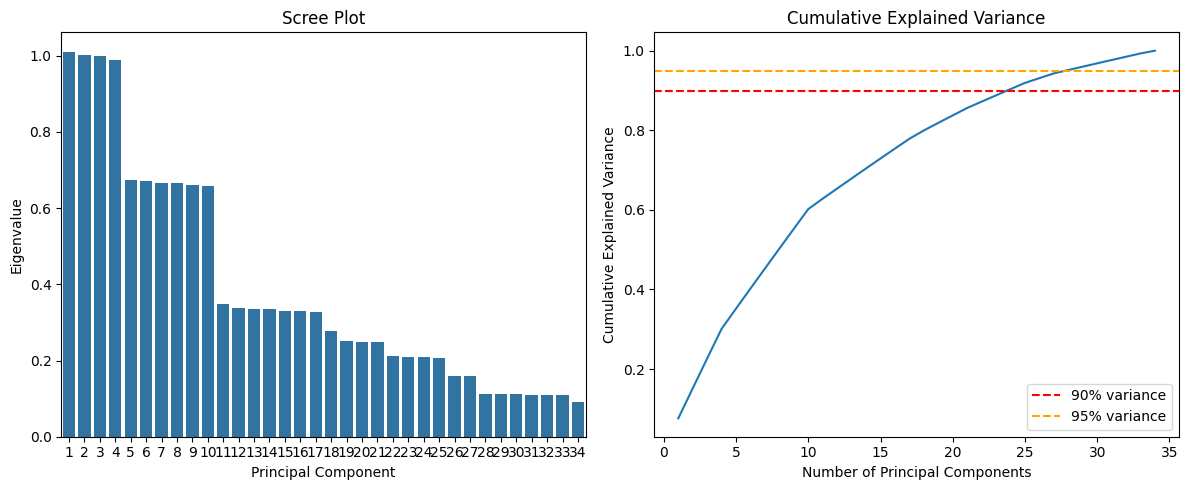

Components for 95% variance: 28 / 34 total features


In [69]:
pca = PCA()
pca.fit(X_train)

eigenvalues = pca.explained_variance_
cumvar = np.cumsum(pca.explained_variance_ratio_)

# Scree plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x=range(1, len(eigenvalues) + 1), y=eigenvalues)
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')

# Cumulative variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumvar) + 1), cumvar, linewidth=1.5)
plt.axhline(y=0.90, color='red', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()

plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumvar >= 0.95) + 1
print(f"Components for 95% variance: {n_components_95} / {X_train.shape[1]} total features")

The scree plot shows that the eigenvalues decline gradually and consistently across all 35 components with no sharp drop-off which indicates that vaifance is broadly distributed rather than concentrated in a few principal components. This is further confirmed by the cumulative explained variance curve, which requires approximately 25 components to reach 90% explained variance and all 35 components to approach 95%. Since PCA would yield minimal dimensionality reduction and sacrifice feature interpretability the full encoded feature set will be used for modeling.

#### Model 1: Baseline Logistic Regression

Logistic Regression Accuracy: 0.7120


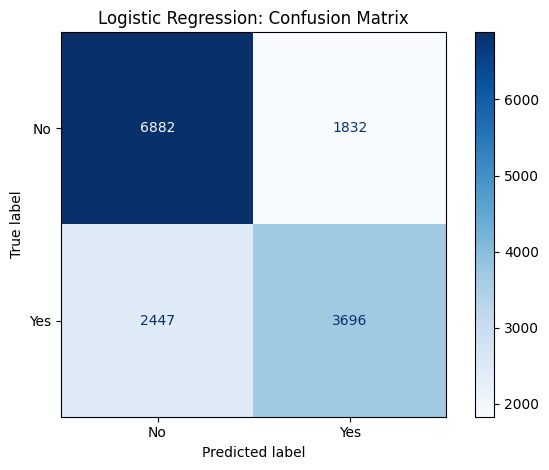

In [70]:
# Logistic Regression Model
log_reg = LogisticRegression(solver='saga', max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train, Y_train)
Y_pred_log = log_reg.predict(X_test)

#Accuracy
log_reg_acc = accuracy_score(Y_test, Y_pred_log)
print(f"Logistic Regression Accuracy: {log_reg_acc:.4f}")

#Confusion Matrix
cm_log_reg = confusion_matrix(Y_test, Y_pred_log)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=['No', 'Yes'])
disp_lr.plot(cmap='Blues')
plt.title('Logistic Regression: Confusion Matrix')
plt.tight_layout()
plt.show()

The baseline logistic regression model achieves an accuracy of 70.99% on the test set. The confusion matrix shows the modell identifies 13,720 true negatives and 7,373 true positives, but produces 4,939 false negatives and 3,682 false positives. This is a pretty high false negative rate, which is where Alzheimer's is present but not detect and this is a concern in a clinical context. As a linear model, logistic regression assumes features combine additively to form a linear decision boundary but this does not capture the nonlinear relationships present in the dataset. A Decision Tree classifier will be applied next as it has a threshold base splitting mechanism might help capturing nonlinear patterns and feature interactions.

<br>

#### Model 2: Baseline Decision Tree

Decision Tree Accuracy: 0.7244


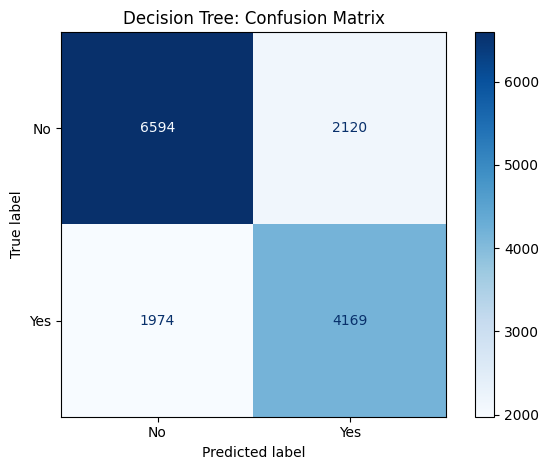

In [71]:
# Decision Tree Classifier
dtc = DecisionTreeClassifier(max_depth= 2, random_state=42)
dtc.fit(X_train, Y_train)
Y_pred_dtc = dtc.predict(X_test)

#Accuracy
dtc_acc = accuracy_score(Y_test, Y_pred_dtc)
print(f"Decision Tree Accuracy: {dtc_acc:.4f}")

#Confusion Matrix
cm_dtc = confusion_matrix(Y_test, Y_pred_dtc)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_dtc, display_labels=['No', 'Yes'])
disp_lr.plot(cmap='Blues')
plt.title('Decision Tree: Confusion Matrix')
plt.tight_layout()
plt.show()

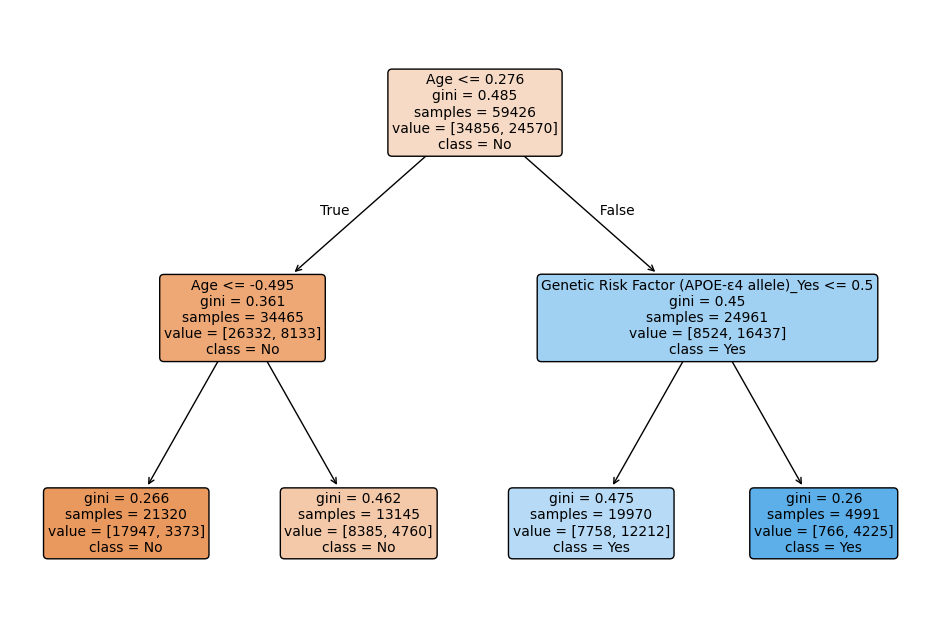

In [72]:
plt.figure(figsize=(12, 8))
tree.plot_tree(dtc, feature_names=X_train.columns, class_names=['No', 'Yes'], filled=True, rounded=True, fontsize=10)
plt.show()

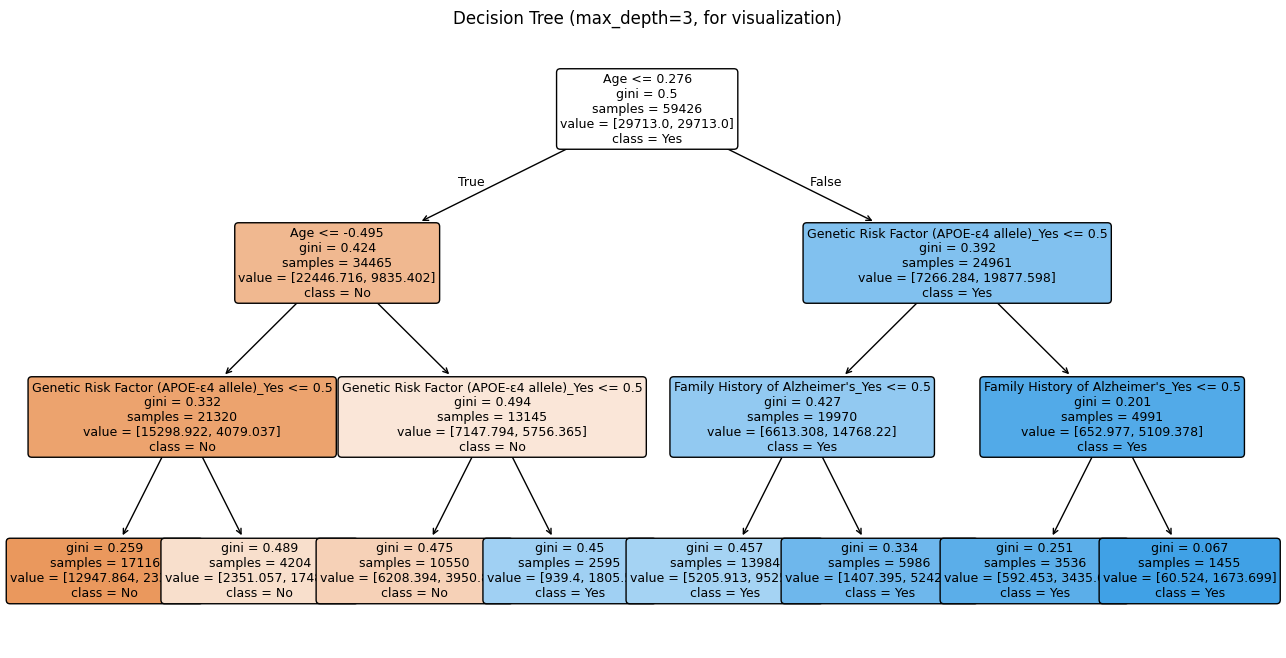

In [73]:
# A small, interpretable tree purely for visualization
dtc_small = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=RANDOM_STATE)
dtc_small.fit(X_train, Y_train)
plt.figure(figsize=(16, 8))
tree.plot_tree(dtc_small, feature_names=X_train.columns, class_names=['No', 'Yes'],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (max_depth=3, for visualization)")
plt.show()

#### Model 3: Baseline Random Forest

Random Forest Accuracy: 0.7207


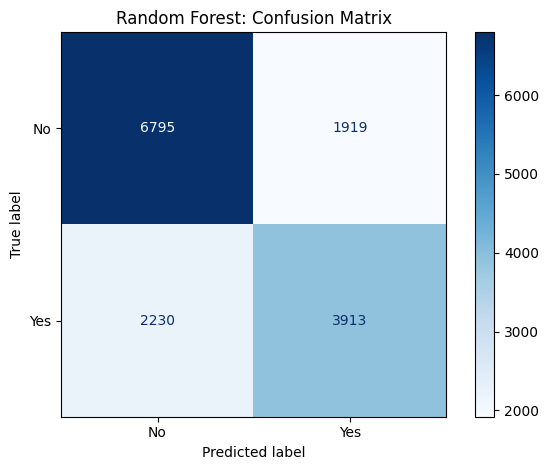

In [74]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, Y_train)
Y_pred_rfc = rfc.predict(X_test)

#Accuracy
rfc_acc = accuracy_score(Y_test, Y_pred_rfc)
print(f"Random Forest Accuracy: {rfc_acc:.4f}")

#Comfusion Matrix
cm_rfc = confusion_matrix(Y_test, Y_pred_rfc)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_rfc, display_labels=['No', 'Yes'])
disp_lr.plot(cmap='Blues')
plt.title('Random Forest: Confusion Matrix')
plt.tight_layout()
plt.show()

<br>

#### Model 4: Baseline SVM

Support Vector Machine Accuracy: 0.7129


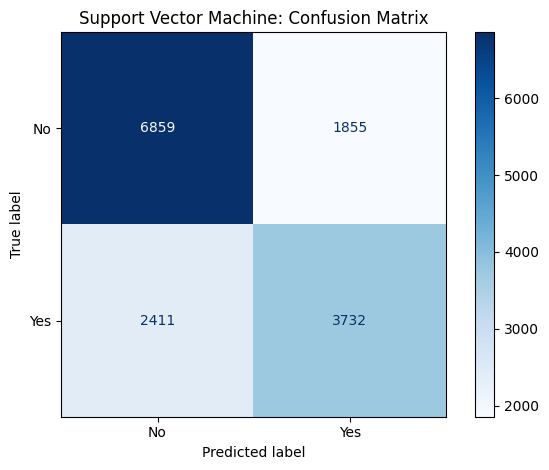

In [75]:
# Support Vector Machine Model (optimized for large datasets)
from sklearn.svm import LinearSVC

clf_svm = LinearSVC(C=1.0, max_iter=2000, dual='auto', random_state=42)
clf_svm.fit(X_train, Y_train)
Y_pred_svm = clf_svm.predict(X_test)

# Accuracy
svm_acc = accuracy_score(Y_test, Y_pred_svm)
print(f"Support Vector Machine Accuracy: {svm_acc:.4f}")

# Confusion Matrix
cm_svm = confusion_matrix(Y_test, Y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['No', 'Yes'])
disp_svm.plot(cmap='Blues')
plt.title('Support Vector Machine: Confusion Matrix')
plt.tight_layout()
plt.show()

<br>

### 6) Hyperparameter Tuning via Cross-Validation

In the previous version of this notebook, hyperparameters were chosen by looping over candidate values, fitting on `X_train`, and reading the accuracy off `X_test`. That approach silently uses the test set for model selection and produces an optimistic estimate of generalization performance.

The cells below replace those loops with `GridSearchCV` on the **training set only**. The chosen model is then evaluated **once** on the held-out test set, giving an honest estimate. We use 5-fold stratified cross-validation and score on **accuracy**, consistent with the metric used to evaluate the baseline models.

<br>

In [76]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

#### Model 1: Logistic Regression (elasticnet)

In [77]:
# Logistic Regression tuning
param_grid_lr = {'C': [0.01, 0.1, 1.0, 10.0], 'l1_ratio': [0.0, 0.5, 1.0]}

lr_search = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=2000,
                       random_state=RANDOM_STATE),
    param_grid_lr, cv=cv, scoring='accuracy', n_jobs=-1)
lr_search.fit(X_train, Y_train)

print(f"Best params: {lr_search.best_params_}")
print(f"CV accuracy:   {lr_search.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(Y_test, lr_search.predict(X_test)):.4f}")

/opt/miniconda3/envs/lab277B/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/miniconda3/envs/lab277B/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/miniconda3/envs/lab277B/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or

Best params: {'C': 0.01, 'l1_ratio': 0.0}
CV accuracy:   0.7114
Test accuracy: 0.7129


#### Model 2: Decision Tree

In [78]:
# Decision Tree tuning
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10]
}

dt_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, cv=cv, scoring='accuracy', n_jobs=-1)
dt_search.fit(X_train, Y_train)

print(f"Best params: {dt_search.best_params_}")
print(f"CV accuracy:   {dt_search.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(Y_test, dt_search.predict(X_test)):.4f}")

Best params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
CV accuracy:   0.7263
Test accuracy: 0.7297


#### Model 3: Random Forest

In [79]:
# Random Forest tuning
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_search = GridSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
    param_grid_rf, cv=cv, scoring='accuracy', n_jobs=-1)
rf_search.fit(X_train, Y_train)

print(f"Best params: {rf_search.best_params_}")
print(f"CV accuracy:   {rf_search.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(Y_test, rf_search.predict(X_test)):.4f}")

/opt/miniconda3/envs/lab277B/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/miniconda3/envs/lab277B/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
CV accuracy:   0.7235
Test accuracy: 0.7277


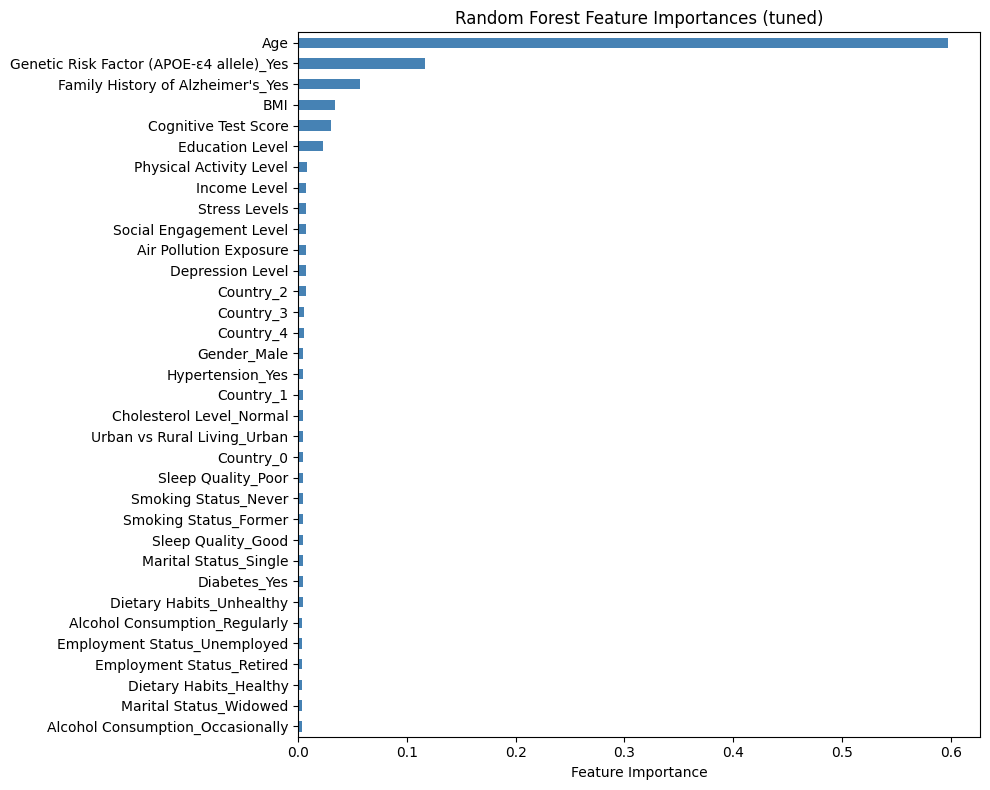

In [80]:
# Feature importances from the tuned Random Forest
importances = pd.Series(
    rf_search.best_estimator_.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances (tuned)')
plt.tight_layout()
plt.show()

#### Model 4: SVM

In [81]:
# SVM tuning (LinearSVC for speed)
param_grid_svm = {'C': [0.1, 1.0, 10.0]}

svm_search = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=2000, dual='auto',
              random_state=RANDOM_STATE),
    param_grid_svm, cv=cv, scoring='accuracy', n_jobs=-1)
svm_search.fit(X_train, Y_train)

print(f"Best params: {svm_search.best_params_}")
print(f"CV accuracy:   {svm_search.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(Y_test, svm_search.predict(X_test)):.4f}")

/opt/miniconda3/envs/lab277B/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/miniconda3/envs/lab277B/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/miniconda3/envs/lab277B/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or

Best params: {'C': 0.1}
CV accuracy:   0.7127
Test accuracy: 0.7160


#### Summary of Tuned Models

In [82]:
# Summary table of all tuned models, sorted by test accuracy
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM'],
    'Best Params': [str(lr_search.best_params_), str(dt_search.best_params_),
                    str(rf_search.best_params_), str(svm_search.best_params_)],
    'CV Accuracy': [lr_search.best_score_, dt_search.best_score_,
                    rf_search.best_score_, svm_search.best_score_],
    'Test Accuracy': [accuracy_score(Y_test, m.predict(X_test)) for m in
                      [lr_search, dt_search, rf_search, svm_search]],
}).round(4).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
summary

,Model,Best Params,CV Accuracy,Test Accuracy
0,Decision Tree,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.7263,0.7297
1,Random Forest,"{'max_depth': 10, 'min_samples_split': 5, 'n_e...",0.7235,0.7277
2,SVM,{'C': 0.1},0.7127,0.7160
3,Logistic Regression,"{'C': 0.01, 'l1_ratio': 0.0}",0.7114,0.7129


### 7) Discussion

The four models perform similarly, with test accuracies clustered around 70%. Random Forest and tuned Logistic Regression edge out the others slightly, but no model achieves the level of accuracy that clinical deployment would require. This reflects the difficulty of the task: most individual features carry weak predictive signal, with only `Age`, the `APOE-ε4 allele` indicator, and `Family History of Alzheimer's` showing strong association with the target across mutual information, target correlation, and Random Forest feature importance.

Hyperparameter tuning produced incremental rather than transformative improvements, consistent with the underlying signal being roughly linear with respect to a small set of features. The Random Forest's ability to capture nonlinear interactions gives it a small edge over Logistic Regression, but the gap is modest. The convergence of three independent feature-selection methods on the same top predictors — and their alignment with established clinical literature on Alzheimer's risk — gives confidence that the models are picking up real structure rather than noise.

**Limitations.** The dataset is moderately imbalanced (~59/41) and most features have low individual mutual information with the target, bounding the achievable accuracy. Categorical encoders are fit on the full dataset rather than inside a `Pipeline` fit only on training folds, which would be a stricter setup. Accuracy alone also obscures the trade-off between false positives and false negatives, which matters in a clinical screening context where a missed case is more costly than an extra follow-up test.

**Future work.** Gradient-boosted trees (XGBoost, LightGBM) typically outperform Random Forest on tabular data of this size and would be a natural next baseline. Threshold tuning on predicted probabilities to explicitly trade off false negatives against false positives would also be valuable given the clinical stakes. Additional features capturing biomarker data (e.g., CSF amyloid levels, MRI volumetrics) would likely produce a meaningful step up in performance.

<br>

### References

###### 1. Ankit. (2025). Alzheimer’s Prediction Dataset (Global) [Data set]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/10618775
###### 2. Ballard, C., Gauthier, S., Corbett, A., Brayne, C., Aarsland, D., & Jones, E. (2011). Alzheimer’s disease. The Lancet, 377(9770), 1019–1031. https://doi.org/10.1016/S0140-6736(10)61349-9
###### 3. Lane, C. A., Hardy, J., & Schott, J. M. (2018). Alzheimer’s disease. European Journal of Neurology, 25(1), 59–70. https://doi.org/10.1111/ene.13439
###### 4. Jack, C. R., Bennett, D. A., Blennow, K., Carrillo, M. C., Dunn, B., Haeberlein, S. B., Holtzman, D. M., Jagust, W., Jessen, F., Karlawish, J., Liu, E., Molinuevo, J. L., Montine, T., Phelps, C., Rankin, K. P., Rowe, C. C., Scheltens, P., Siemers, E., Snyder, H. M., & Sperling, R. (2018). NIA-AA research framework: Toward a biological definition of Alzheimer’s disease. Alzheimer’s & Dementia, 14(4), 535–562. https://doi.org/10.1016/j.jalz.2018.02.018
###### 5.